Eigenvalues (descending):
 1: 8.187e+00
 2: 1.015e-01
 3: 3.544e-04
 4: 2.743e-04
 5: 1.353e-04
 6: 7.765e-09


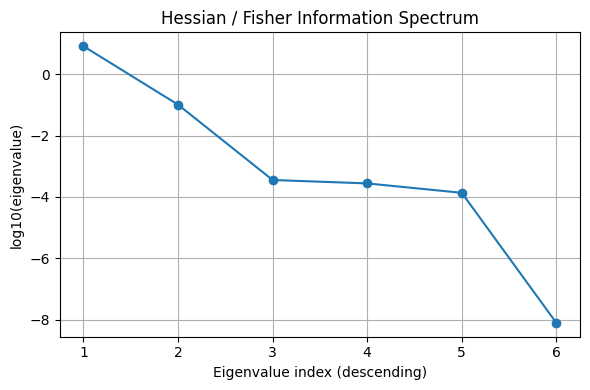


Eigenvector 1 (lambda=8.187e+00):
    k1_aa_over_CT: -0.589
            k3_CT: -0.000
               k4: -0.417
          k4prime: -0.186
               k6: +0.667
               k7: -0.000

Eigenvector 2 (lambda=1.015e-01):
    k1_aa_over_CT: -0.772
            k3_CT: +0.001
               k4: +0.274
          k4prime: +0.415
               k6: -0.395
               k7: +0.004

Eigenvector 3 (lambda=3.544e-04):
    k1_aa_over_CT: +0.233
            k3_CT: +0.000
               k4: -0.181
          k4prime: +0.874
               k6: +0.337
               k7: +0.186

Eigenvector 4 (lambda=2.743e-04):
    k1_aa_over_CT: -0.042
            k3_CT: -0.001
               k4: -0.012
          k4prime: -0.166
               k6: -0.090
               k7: +0.981
eigvals sorted (desc): [8.18676459e+00 1.01473158e-01 3.54427789e-04 2.74331701e-04
 1.35317273e-04 7.76482436e-09]
ratio largest/smallest (use smallest > 0): 1054339958.1012971
log10 span: 9.022980666021034
H diagonal: [2.90158392e+00 

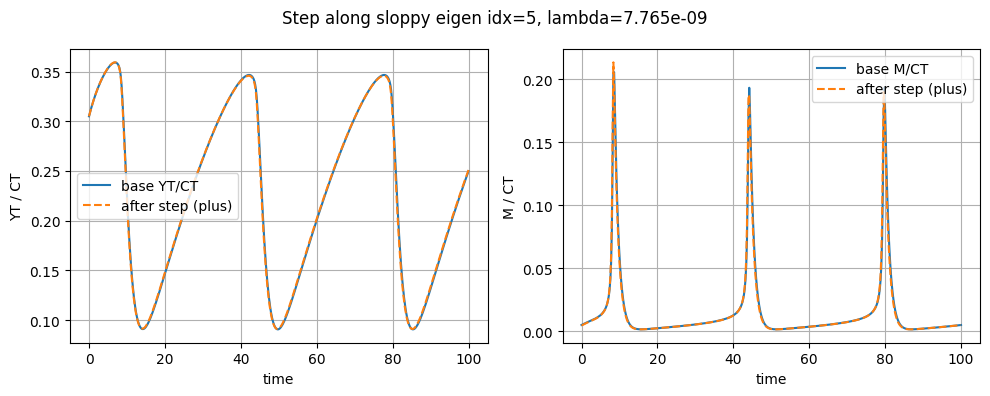

In [9]:
# Sloppiness analysis for the Tyson-like 6-state ODE example
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from numpy.linalg import eigh

# === Base parameters (user provided) ===
p = {
    "k1_aa_over_CT": 0.015,
    "k2": 0.0,
    "k3_CT": 200.0,
    "k4": 180.0,
    "k4prime": 0.018,
    "k5_minusP": 0.0,
    "k6": 1.0,
    "k7": 0.6,
    "k8_minusP": 100.0,
    "k9": 50.0,
    "CT": 1.0
}

# We'll analyze these parameters (drop k2 and k5_minusP; add k8_minusP and k9)
param_names = [
    "k1_aa_over_CT",
    "k3_CT",
    "k4",
    "k4prime",
    "k6",
    "k7"
    #,"k8_minusP",
    #,"k9"
]
pvec = np.array([p[name] for name in param_names])
p_index = {name:i for i,name in enumerate(param_names)}
P = len(param_names)


# === model right-hand side and helper functions ===
CT = p["CT"]

def F_M(M, p):
    return p["k4prime"] + p["k4"] * (M / p["CT"])**2

def dF_dM(M, p):
    # derivative of F_M wrt M
    return p["k4"] * 2.0 * (M / p["CT"]) * (1.0 / p["CT"])

def f_rhs(t, x, p):
    # x = [C2, CP, pM, M, Y, YP]
    C2, CP, pM, M, Y, YP = x
    k3 = p["k3_CT"] / p["CT"]
    k1 = p["k1_aa_over_CT"] * p['CT']
    dC2 = p["k6"] * M - p["k8_minusP"] * C2 + p["k9"] * CP
    dCP = -k3 * CP * Y + p["k8_minusP"] * C2 - p["k9"] * CP
    dpM = k3 * CP * Y - pM * F_M(M, p) + p["k5_minusP"] * M
    dM  = pM * F_M(M, p) - p["k5_minusP"] * M - p["k6"] * M
    dY  = k1 - p["k2"] * Y - k3 * CP * Y
    dYP = p["k6"] * M - p["k7"] * YP
    return np.array([dC2, dCP, dpM, dM, dY, dYP])

def jacobian_fx(x, p):
    """Compute df/dx (6x6) analytically at state x."""
    C2, CP, pM, M, Y, YP = x
    k3 = p["k3_CT"] / p["CT"]
    # dF/dM
    dF = dF_dM(M, p)
    J = np.zeros((6,6))
    # dC2
    J[0,0] = -p["k8_minusP"]    # d(dC2)/dC2
    J[0,1] = p["k9"]           # d(dC2)/dCP
    J[0,3] = p["k6"]           # d(dC2)/dM
    # dCP
    J[1,0] = p["k8_minusP"]
    J[1,1] = -k3*Y - p["k9"]
    J[1,4] = -k3*CP
    # dpM
    J[2,1] = k3*Y
    J[2,2] = -F_M(M, p)
    J[2,3] = -pM * dF + p["k5_minusP"]
    J[2,4] = k3*CP
    # dM
    J[3,2] = F_M(M, p)
    J[3,3] = pM * dF - p["k5_minusP"] - p["k6"]
    # dY
    k1 = p["k1_aa_over_CT"] * p['CT']
    J[4,1] = -k3 * Y
    J[4,4] = -p["k2"] - k3 * CP
    # dYP
    J[5,3] = p["k6"]
    J[5,5] = -p["k7"]
    return J

def df_dparam(x, p):
    """Compute df/dh for each parameter in param_names (returns 6 x P array).
       Now supports parameters: k1_aa_over_CT, k3_CT, k4, k4prime, k6, k7, k8_minusP, k9
    """
    C2, CP, pM, M, Y, YP = x
    k3 = p["k3_CT"] / p["CT"]
    # precompute pieces
    dfdh = np.zeros((6, P))
    for j,name in enumerate(param_names):
        if name == "k1_aa_over_CT":
            # k1 = k1_aa_over_CT * CT appears only in dY as +k1
            df = np.zeros(6); df[4] = p['CT']  # d(dY)/d k1_aa_over_CT = CT
            dfdh[:,j] = df
        elif name == "k3_CT":
            # k3 = k3_CT / CT
            coeff = 1.0 / p["CT"]
            df = np.zeros(6)
            df[1] = -coeff * CP * Y     # d(dCP)/d k3_CT
            df[2] =  coeff * CP * Y     # d(dpM)/d k3_CT
            df[4] = -coeff * CP * Y     # d(dY)/d k3_CT
            dfdh[:,j] = df
        elif name == "k4":
            df = np.zeros(6)
            dFdk4 = (M / p["CT"])**2
            df[2] = -pM * dFdk4   # dpM
            df[3] =  pM * dFdk4   # dM
            dfdh[:,j] = df
        elif name == "k4prime":
            df = np.zeros(6)
            dFdk4p = 1.0
            df[2] = -pM * dFdk4p
            df[3] =  pM * dFdk4p
            dfdh[:,j] = df
        elif name == "k6":
            df = np.zeros(6)
            df[0] = M          # d(dC2)/d k6 = M
            df[3] = -M         # d(dM)/d k6 = -M
            df[5] = M          # d(dYP)/d k6 = M
            dfdh[:,j] = df
        elif name == "k7":
            df = np.zeros(6)
            df[5] = -YP        # d(dYP)/d k7 = -YP
            dfdh[:,j] = df
        elif name == "k8_minusP":
            # k8 multiplies C2 with + in dCP and - in dC2
            df = np.zeros(6)
            df[0] = -C2        # d(dC2)/d k8 = -C2
            df[1] =  C2        # d(dCP)/d k8 = +C2
            dfdh[:,j] = df
        elif name == "k9":
            # k9 multiplies CP with + in dC2 and - in dCP
            df = np.zeros(6)
            df[0] =  CP        # d(dC2)/d k9 = +CP
            df[1] = -CP        # d(dCP)/d k9 = -CP
            dfdh[:,j] = df
        else:
            raise KeyError(name)
    return dfdh



# === Sensitivity ODE: augmented system ===
def augmented_rhs(t, z):
    """z contains [x(6), S_flat(6*P)] where S_j are sensitivities wrt log-params:
       S_j = d x / d log(h_j) = h_j * d x / d h_j.
    """
    x = z[:6]
    S_flat = z[6:]
    S = S_flat.reshape((6, P), order='F')  # columns are parameters
    # compute base dynamics
    xdot = f_rhs(t, x, p)
    # compute df/dx and df/dparam
    A = jacobian_fx(x, p)            # 6x6
    df_dh = df_dparam(x, p)         # 6xP (∂f/∂h)
    # convert df/dh to df/dlogh: df/dlogh = h * df/dh  (elementwise scalar multiply)
    df_dlogh = np.zeros_like(df_dh)
    for j,name in enumerate(param_names):
        hj = p[name]
        df_dlogh[:, j] = hj * df_dh[:, j]
    # sensitivity ODEs: dS_j/dt = A * S_j + df/dlogh_j
    Sdot = A.dot(S) + df_dlogh
    # pack
    return np.concatenate([xdot, Sdot.ravel(order='F')])

# === Integration ===
y0 = np.array([0.9, 0.05, 0.0, 0.005, 0.3, 0.0])
# initial sensitivities: ∂x(0)/∂log h_j ; if x0 independent of params -> zeros
S0 = np.zeros((6, P))
z0 = np.concatenate([y0, S0.ravel(order='F')])

t_span = (0.0, 100.0)
# choose times where we want to evaluate (optional)
t_eval = np.linspace(t_span[0], t_span[1], 1001)

sol_aug = solve_ivp(augmented_rhs, t_span, z0, method='BDF',
                    t_eval=t_eval, rtol=1e-6, atol=1e-8)

if not sol_aug.success:
    raise RuntimeError("Augmented integration failed: " + sol_aug.message)

t = sol_aug.t
X = sol_aug.y[:6, :]                       # 6 x m
S_flat = sol_aug.y[6:, :]                  # (6*P) x m
m = t.size

# reshape sensitivities: for each time i, S(:,:,i) is 6 x P
S_time = np.zeros((6, P, m))
for i in range(m):
    S_time[:,:,i] = S_flat[:,i].reshape((6,P), order='F')

# === Observables and output sensitivities ===
# Here g(x,h) = x (identity). So output sensitivity rows are simply S_time (state sensitivities).
# If you had a different g, you'd compute dg/dx @ S + dg/dlogh.
J_time = S_time.copy()   # shape (6, P, m) — observables x params x time

# === Build weighting matrix W and quadrature weights ===
Ns = 6           # number of species/observables
Nc = 1           # only one condition
Tc = t_span[1] - t_span[0]
sigma = 1.0      # per-species measurement noise (1 if unknown)
# diagonal weights per observable: each of the 6 species has same sigma here
W_diag = np.ones(Ns) * (1.0 / (Nc * Ns * Tc * sigma**2))
W = np.diag(W_diag)   # shape (6,6)

# quadrature weights (trapezoid)
dt = np.diff(t)
q = np.zeros(m)
q[0] = dt[0]/2.0
q[-1] = dt[-1]/2.0
q[1:-1] = 0.5*(dt[:-1] + dt[1:])

# === Accumulate H ===
H = np.zeros((P, P))
for i in range(m):
    J_i = J_time[:, :, i]        # (6 x P)
    A_i = J_i.T.dot(W).dot(J_i)  # P x P
    H += q[i] * A_i


# === Eigen-decompose H ===
eigvals, eigvecs = eigh(H)   # ascending
eigvals = eigvals[::-1]      # descending
eigvecs = eigvecs[:, ::-1]

# print eigenvalues and condition number
print("Eigenvalues (descending):")
for i, lam in enumerate(eigvals):
    print(f"{i+1:2d}: {lam:.3e}")


# === Plot spectrum ===
plt.figure(figsize=(6,4))
plt.plot(np.arange(1, P+1), np.log10(eigvals), 'o-')
plt.xlabel("Eigenvalue index (descending)")
plt.ylabel("log10(eigenvalue)")
plt.title("Hessian / Fisher Information Spectrum")
plt.grid(True)
plt.tight_layout()
plt.show()

# === Optional: inspect top eigenvector composition (which parameters dominate) ===
top_k = min(4, P)
for k in range(top_k):
    vec = eigvecs[:,k]
    print(f"\nEigenvector {k+1} (lambda={eigvals[k]:.3e}):")
    for j,name in enumerate(param_names):
        print(f"  {name:>15s}: {vec[j]:+.3f}")

import numpy as np

# 1) condition number and spread
eigvals_raw, _ = np.linalg.eig(H)
eigvals_real = np.real(eigvals_raw)  # numerical safety
eigvals_sorted = np.sort(eigvals_real)[::-1]
print("eigvals sorted (desc):", eigvals_sorted)
print("ratio largest/smallest (use smallest > 0):",
      eigvals_sorted[0] / max(eigvals_sorted[-1], 1e-300))
print("log10 span:", np.log10(eigvals_sorted[0]) - np.log10(max(eigvals_sorted[-1],1e-300)))

# 2) check H diagonal (which gives marginal info for each param)
print("H diagonal:", np.diag(H))

# 3) column norms of J (integrated contribution per parameter)
col_sq = np.sum([ (J_time[:,j,i]**2).sum() * q[i] for i in range(m) for j in range(P) ])
# simpler: compute L2 norm per parameter by integrating J(:,j,:)^2 over time
col_norms = np.zeros(P)
for j in range(P):
    col_norms[j] = sum(q[i] * np.sum(J_time[:, j, i]**2) for i in range(m))
print("per-parameter integrated squared-sensitivity (col_norms):", col_norms)

# 4) check for zero parameters in pvec
print("parameter vector:", pvec)


def simulate_at_params(p_local, t_eval):
    y0 = np.array([0.9, 0.05, 0.0, 0.005, 0.3, 0.0])
    sol = solve_ivp(lambda tt, xx: f_rhs(tt, xx, p_local), (t_eval[0], t_eval[-1]), y0,
                    method='BDF', t_eval=t_eval, rtol=1e-6, atol=1e-8)
    if not sol.success:
        raise RuntimeError("Integrator failed: " + sol.message)
    return sol.t, sol.y  # t, (6 x m)

# choose index of smallest positive eigenvalue (most sloppy)
pos_idx = np.where(eigvals > 1e-30)[0]
if pos_idx.size == 0:
    raise RuntimeError("No positive eigenvalues found.")
sloppy_idx = pos_idx[-1]
lam = eigvals[sloppy_idx]
v = eigvecs[:, sloppy_idx]

print(f"Chosen sloppy eigen idx={sloppy_idx}, lambda={lam:.3e}")

# step size (quadratic rule)
delta = 0.1
alpha = np.sqrt(delta / max(lam, 1e-300))
max_logstep = 10
alpha = min(alpha, max_logstep)
dlogh = alpha * v
dlogh = np.clip(dlogh, -2.0, 2.0)  # safety clamp

# parameter names -> p vectors mapping (current)
p_current = dict(p)  # copy
P = len(param_names)

# build p_plus and p_minus
p_plus = dict(p_current)
p_minus = dict(p_current)

for j, name in enumerate(param_names):
    p_plus[name]  = p_current[name] * np.exp(+dlogh[j])
    p_minus[name] = p_current[name] * np.exp(-dlogh[j])


# choose time grid (reuse from your sensitivity run if available)
t_eval = np.linspace(0, 100, 501)

# simulate baseline and both candidates
t0, X0 = simulate_at_params(p_current, t_eval)
t_p, Xp = simulate_at_params(p_plus,  t_eval)
t_m, Xm = simulate_at_params(p_minus, t_eval)

# compute YT_rel and M_rel (use current CT)
CT_local = p_current['CT']
def compute_obs(X):
    C2, CP, pM, M, Y, YP = X
    YT = Y + YP + pM + M
    return YT / CT_local, M / CT_local

YT0, M0 = compute_obs(X0)
YTp, Mp = compute_obs(Xp)
YTm, Mm = compute_obs(Xm)

# approximate integrated squared difference (Euclidean with trapezoid weights)
dt = np.diff(t_eval)
q = np.zeros_like(t_eval)
q[0] = dt[0]/2.0; q[-1] = dt[-1]/2.0
q[1:-1] = 0.5*(dt[:-1] + dt[1:])

def integrated_sq_diff(YA, YB):
    return np.sum(q * ( (YA - YB)**2 ))

score_plus  = integrated_sq_diff(YT0, YTp) + integrated_sq_diff(M0, Mp)
score_minus = integrated_sq_diff(YT0, YTm) + integrated_sq_diff(M0, Mm)

# pick the better sign
if score_plus <= score_minus:
    score = score_plus
    chosen = 'plus'
    p_next = p_plus
    YT_next, M_next = YTp, Mp
else:
    chosen = 'minus'
    score = score_minus
    p_next = p_minus
    YT_next, M_next = YTm, Mm

print("---------Step result---------")
print("Picked direction:", chosen, "alpha:", alpha)
print('difference in parameters:', {name: (p_next[name] - p_current[name]) for name in param_names})
print('total  distance between P_current and P_next:',
      np.sqrt( sum( ((p_next[name]) - (p_current[name]))**2 for name in param_names ) ) )
print('new parameters:', {name: p_next[name] for name in param_names})
print('integrated squared-output-change at chosen step:', score)
# plot overlay
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(t_eval, YT0, label='base YT/CT', lw=1.5)
plt.plot(t_eval, YT_next, '--', label=f'after step ({chosen})', lw=1.5)
plt.xlabel('time')
plt.ylabel('YT / CT')
plt.legend(); plt.grid(True)

plt.subplot(1,2,2)
plt.plot(t_eval, M0, label='base M/CT', lw=1.5)
plt.plot(t_eval, M_next, '--', label=f'after step ({chosen})', lw=1.5)
plt.xlabel('time')
plt.ylabel('M / CT')
plt.legend(); plt.grid(True)

plt.suptitle(f"Step along sloppy eigen idx={sloppy_idx}, lambda={lam:.3e}")
plt.tight_layout()
plt.show()



In [10]:
# === Settings for parameter tweaking ===
# Choose which parameters to tweak (set True to tweak, False to keep constant)
params_to_tweak = {
    "k1_aa_over_CT": False,
    "k3_CT": True,
    "k4": False,
    "k4prime": False,
    "k6": False,
    "k7": True
}

# Tweaking parameters
n_steps = 50           # number of steps to take
log_step = 0.05        # constant log step size (parameter *= exp(log_step) each step)


Will tweak each parameter separately: ['k3_CT', 'k7']
Settings: n_steps = 50, log_step = 0.05




Tweaking parameter: k3_CT
  Step 10/50
  Step 10/50
  Step 20/50
  Step 20/50
  Step 30/50
  Step 30/50
  Step 40/50
  Step 40/50
  Step 50/50
  Completed! k3_CT: 200 → 2436.5

Tweaking parameter: k7
  Step 50/50
  Completed! k3_CT: 200 → 2436.5

Tweaking parameter: k7
  Step 10/50
  Step 10/50
  Step 20/50
  Step 20/50
  Step 30/50
  Step 30/50
  Step 40/50
  Step 40/50
  Step 50/50
  Completed! k7: 0.6 → 7.3095

All parameter tweaking completed!


k3_CT: 200 → 2436.5
  Step 50/50
  Completed! k7: 0.6 → 7.3095

All parameter tweaking completed!


k3_CT: 200 → 2436.5


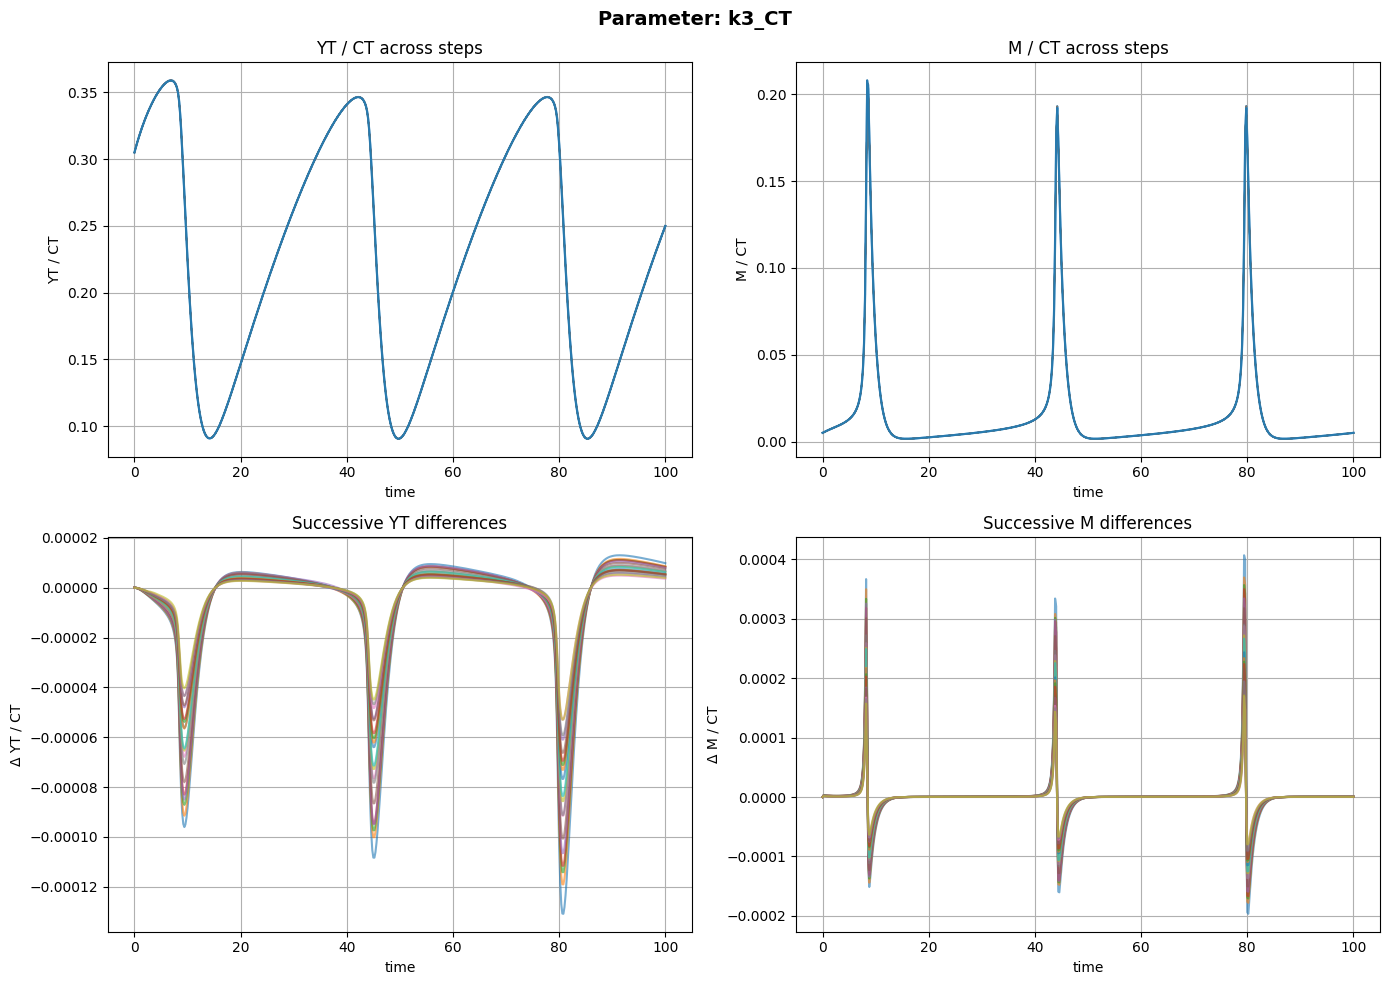


k7: 0.6 → 7.3095


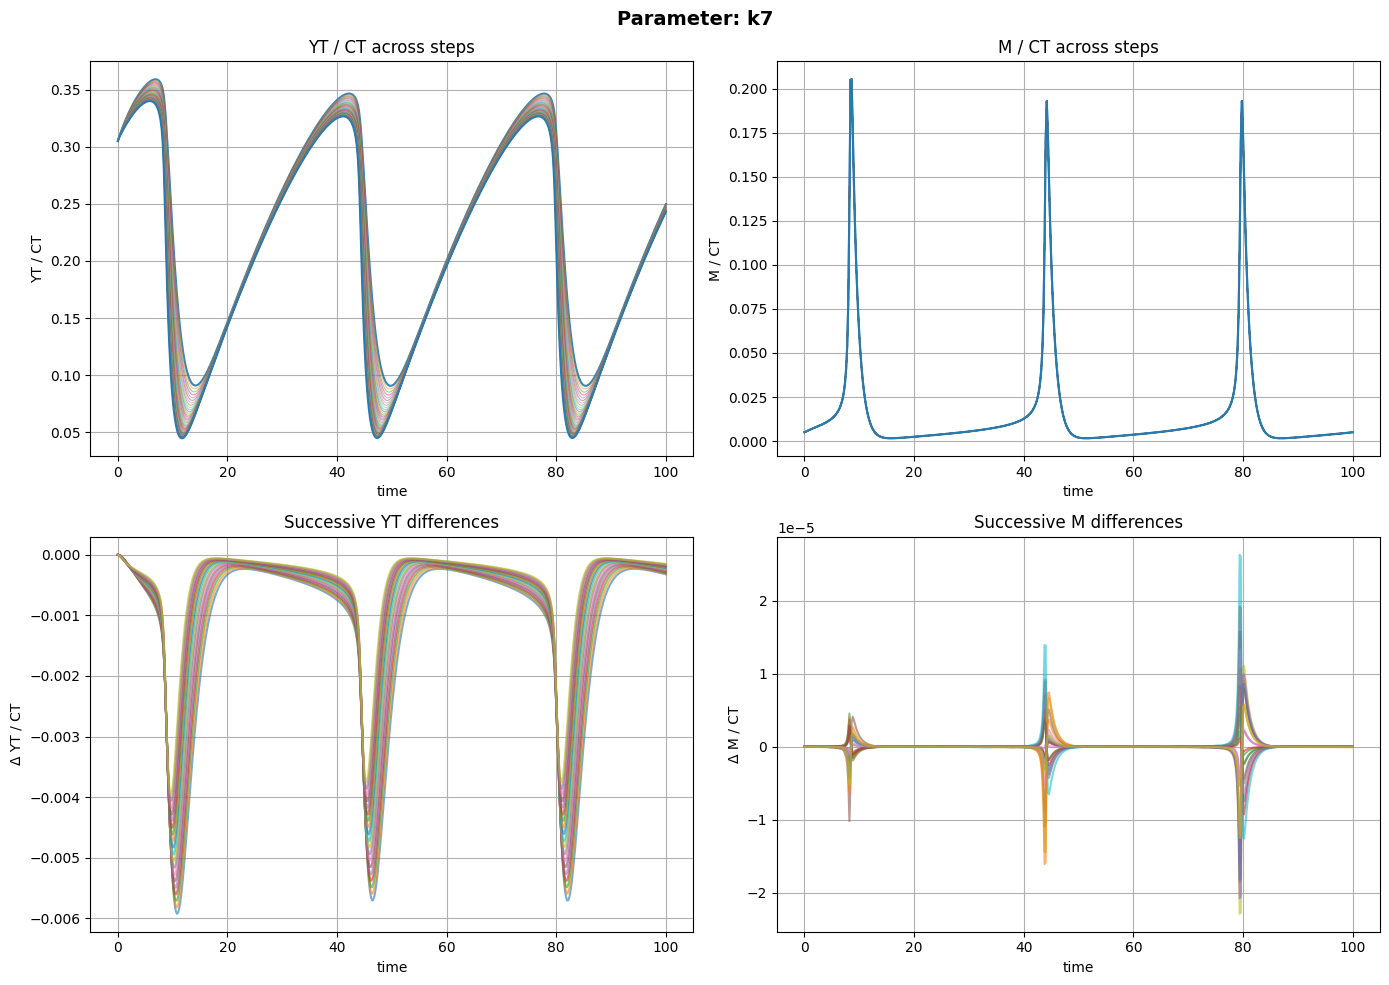

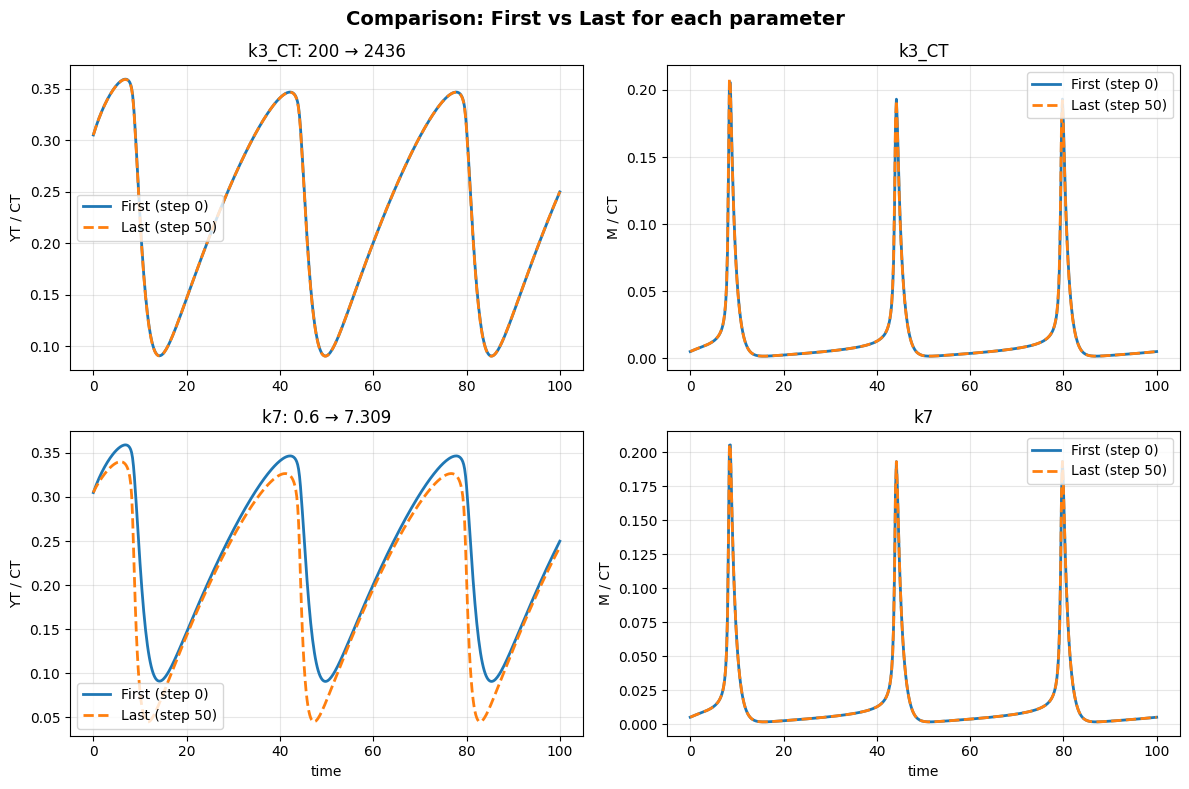

In [11]:
# ----------------------------
# Iterative parameter tweaking block
# Tweaks each selected parameter SEPARATELY and stores results
# ----------------------------

import copy
from scipy.integrate import solve_ivp

# Get list of parameters to tweak
params_to_analyze = [name for name in param_names if params_to_tweak.get(name, False)]

if len(params_to_analyze) == 0:
    print("No parameters selected for tweaking! Please set at least one parameter to True in params_to_tweak.")
else:
    print(f"\nWill tweak each parameter separately: {params_to_analyze}")
    print(f"Settings: n_steps = {n_steps}, log_step = {log_step}\n")

# Store results for each parameter separately
all_results = {}  # key: param_name, value: dict with histories

# Simulate baseline once
t_base, X_base = simulate_at_params(p, t_eval)
YT_base, M_base = compute_obs(X_base)

# Loop through each parameter to tweak
for param_to_tweak in params_to_analyze:
    print(f"\n{'='*60}")
    print(f"Tweaking parameter: {param_to_tweak}")
    print(f"{'='*60}")
    
    # Prepare storage for this parameter
    param_history = []
    obs_history = []
    
    # Initialize p_current from base parameters
    p_current = dict(p)
    param_history.append(copy.deepcopy(p_current))
    obs_history.append((YT_base.copy(), M_base.copy()))
    
    # Iterate tweaking only this parameter
    for step in range(1, n_steps+1):
        if step % 10 == 0:
            print(f"  Step {step}/{n_steps}")
        
        # Build next parameter set by tweaking ONLY the current parameter
        p_next = dict(p_current)
        p_next[param_to_tweak] = p_current[param_to_tweak] * np.exp(log_step)
        
        # Simulate with new parameters
        _, X_next = simulate_at_params(p_next, t_eval)
        YT_next, M_next = compute_obs(X_next)
        
        # Store histories
        param_history.append(copy.deepcopy(p_next))
        obs_history.append((YT_next.copy(), M_next.copy()))
        
        # Update p_current for next iteration
        p_current = p_next
    
    # Store results for this parameter
    all_results[param_to_tweak] = {
        'param_history': param_history,
        'obs_history': obs_history,
        'n_recorded': len(param_history)
    }
    
    print(f"  Completed! {param_to_tweak}: {p[param_to_tweak]:.6g} → {p_current[param_to_tweak]:.6g}")

print(f"\n{'='*60}")
print(f"All parameter tweaking completed!")
print(f"{'='*60}\n")

# ========== Plotting - Separate plots for each parameter ==========
import matplotlib.pyplot as plt

for param_name in params_to_analyze:
    results = all_results[param_name]
    obs_history = results['obs_history']
    param_history = results['param_history']
    n_recorded = results['n_recorded']
    
    print(f"\n{param_name}: {param_history[0][param_name]:.6g} → {param_history[-1][param_name]:.6g}")
    
    # Create figure with 4 subplots for this parameter
    fig = plt.figure(figsize=(14, 10))
    fig.suptitle(f'Parameter: {param_name}', fontsize=14, fontweight='bold')
    
    # 1) YT overlay
    ax1 = plt.subplot(2,2,1)
    for i,(YT_i, M_i) in enumerate(obs_history):
        label = 'step 0' if i==0 else f'step {i}'
        alpha_val = 0.9 if i == 0 or i == n_recorded-1 else 0.5
        lw_val = 1.5 if i == 0 or i == n_recorded-1 else 0.8
        ax1.plot(t_eval, YT_i, label=label, lw=lw_val, alpha=alpha_val)
    ax1.set_xlabel('time')
    ax1.set_ylabel('YT / CT')
    ax1.set_title('YT / CT across steps')
    ax1.grid(True)
    if n_recorded <= 15:
        ax1.legend(fontsize=8)
    
    # 2) M overlay
    ax2 = plt.subplot(2,2,2)
    for i,(YT_i, M_i) in enumerate(obs_history):
        label = 'step 0' if i==0 else f'step {i}'
        alpha_val = 0.9 if i == 0 or i == n_recorded-1 else 0.5
        lw_val = 1.5 if i == 0 or i == n_recorded-1 else 0.8
        ax2.plot(t_eval, M_i, label=label, lw=lw_val, alpha=alpha_val)
    ax2.set_xlabel('time')
    ax2.set_ylabel('M / CT')
    ax2.set_title('M / CT across steps')
    ax2.grid(True)
    if n_recorded <= 15:
        ax2.legend(fontsize=8)
    
    # 3) YT successive differences
    ax3 = plt.subplot(2,2,3)
    for i in range(1, min(n_recorded, 20)):
        Yprev, Mprev = obs_history[i-1]
        Ycurr, Mcurr = obs_history[i]
        diffY = Ycurr - Yprev
        ax3.plot(t_eval, diffY, label=f'{i-1}→{i}', alpha=0.6)
    ax3.set_xlabel('time')
    ax3.set_ylabel('Δ YT / CT')
    ax3.set_title('Successive YT differences')
    ax3.grid(True)
    if n_recorded <= 15:
        ax3.legend(fontsize=7)
    
    # 4) M successive differences
    ax4 = plt.subplot(2,2,4)
    for i in range(1, min(n_recorded, 20)):
        Yprev, Mprev = obs_history[i-1]
        Ycurr, Mcurr = obs_history[i]
        diffM = Mcurr - Mprev
        ax4.plot(t_eval, diffM, label=f'{i-1}→{i}', alpha=0.6)
    ax4.set_xlabel('time')
    ax4.set_ylabel('Δ M / CT')
    ax4.set_title('Successive M differences')
    ax4.grid(True)
    if n_recorded <= 15:
        ax4.legend(fontsize=7)
    
    plt.tight_layout()
    plt.show()

# ========== Comparison plot across all parameters ==========
if len(params_to_analyze) > 1:
    fig, axes = plt.subplots(len(params_to_analyze), 2, figsize=(12, 4*len(params_to_analyze)))
    fig.suptitle('Comparison: First vs Last for each parameter', fontsize=14, fontweight='bold')
    
    for idx, param_name in enumerate(params_to_analyze):
        results = all_results[param_name]
        obs_history = results['obs_history']
        param_history = results['param_history']
        
        YT_first, M_first = obs_history[0]
        YT_last, M_last = obs_history[-1]
        
        # Handle single vs multiple subplots
        if len(params_to_analyze) == 1:
            ax_yt = axes[0]
            ax_m = axes[1]
        else:
            ax_yt = axes[idx, 0]
            ax_m = axes[idx, 1]
        
        # YT comparison
        ax_yt.plot(t_eval, YT_first, label='First (step 0)', lw=2, color='C0')
        ax_yt.plot(t_eval, YT_last, label=f'Last (step {len(obs_history)-1})', lw=2, color='C1', linestyle='--')
        ax_yt.set_ylabel('YT / CT')
        ax_yt.set_title(f'{param_name}: {param_history[0][param_name]:.4g} → {param_history[-1][param_name]:.4g}')
        ax_yt.legend()
        ax_yt.grid(True, alpha=0.3)
        
        # M comparison
        ax_m.plot(t_eval, M_first, label='First (step 0)', lw=2, color='C0')
        ax_m.plot(t_eval, M_last, label=f'Last (step {len(obs_history)-1})', lw=2, color='C1', linestyle='--')
        ax_m.set_ylabel('M / CT')
        ax_m.set_title(f'{param_name}')
        ax_m.legend()
        ax_m.grid(True, alpha=0.3)
        
        # Add x-label only to bottom row
        if idx == len(params_to_analyze) - 1:
            ax_yt.set_xlabel('time')
            ax_m.set_xlabel('time')
    
    plt.tight_layout()
    plt.show()

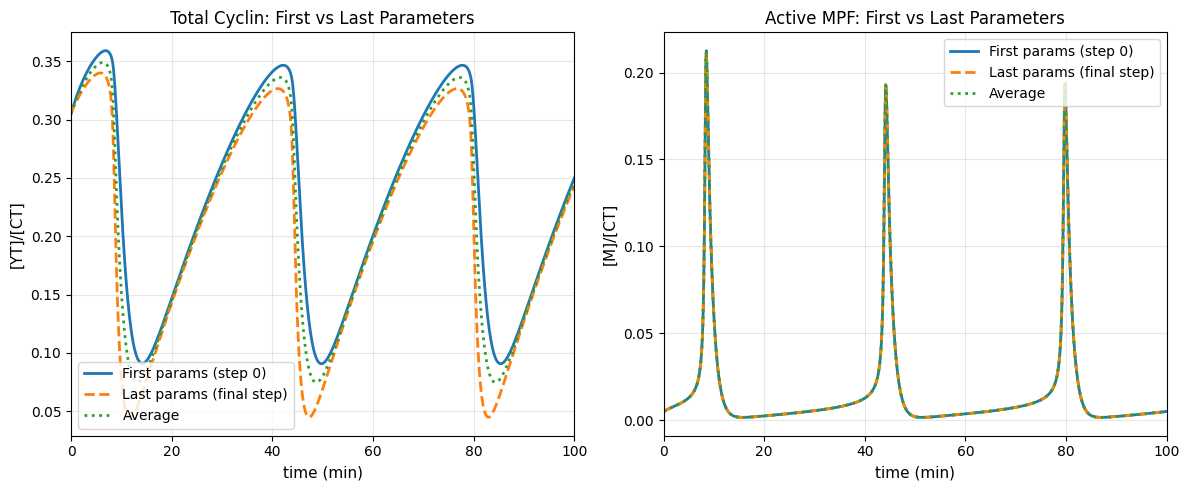


First parameter set (step 0):
  k1_aa_over_CT: 0.015
  k3_CT: 200
  k4: 180
  k4prime: 0.018
  k6: 1
  k7: 0.6

Last parameter set (step 50):
  k1_aa_over_CT: 0.015
  k3_CT: 200
  k4: 180
  k4prime: 0.018
  k6: 1
  k7: 7.3095


In [12]:
# === Comparison plot: First vs Last parameter set (time 0-100) ===
# Get first and last parameter sets from history
p_first = param_history[0]
p_last = param_history[-1]

# Initial conditions
y0 = np.array([0.9, 0.05, 0.0, 0.005, 0.3, 0.0])
t_span = (0, 100)
t_eval = np.linspace(0, 100, 1000)

# Simulate with first parameter set
sol_first = solve_ivp(lambda t, x: f_rhs(t, x, p_first), t_span, y0, 
                       t_eval=t_eval, method='BDF', rtol=1e-6, atol=1e-8)

# Simulate with last parameter set
sol_last = solve_ivp(lambda t, x: f_rhs(t, x, p_last), t_span, y0,
                      t_eval=t_eval, method='BDF', rtol=1e-6, atol=1e-8)

# Extract observables for first params
t_first = sol_first.t
y_first = sol_first.y
M_first = y_first[3]
Y_first, YP_first, pM_first = y_first[4], y_first[5], y_first[2]
YT_first = Y_first + YP_first + pM_first + M_first
M_rel_first = M_first / CT
YT_rel_first = YT_first / CT

# Extract observables for last params
t_last = sol_last.t
y_last = sol_last.y
M_last = y_last[3]
Y_last, YP_last, pM_last = y_last[4], y_last[5], y_last[2]
YT_last = Y_last + YP_last + pM_last + M_last
M_rel_last = M_last / CT
YT_rel_last = YT_last / CT

# Compute averages
YT_rel_avg = (YT_rel_first + YT_rel_last) / 2.0
M_rel_avg = (M_rel_first + M_rel_last) / 2.0

# Create comparison plots
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(t_first, YT_rel_first, lw=2, label='First params (step 0)', color='C0')
plt.plot(t_last, YT_rel_last, lw=2, label='Last params (final step)', color='C1', linestyle='--')
plt.plot(t_first, YT_rel_avg, lw=2, label='Average', color='C2', linestyle=':')
plt.xlim(0,100)
plt.xlabel('time (min)', fontsize=11)
plt.ylabel('[YT]/[CT]', fontsize=11)
plt.title('Total Cyclin: First vs Last Parameters', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1,2,2)
plt.plot(t_first, M_rel_first, lw=2, label='First params (step 0)', color='C0')
plt.plot(t_last, M_rel_last, lw=2, label='Last params (final step)', color='C1', linestyle='--')
plt.plot(t_first, M_rel_avg, lw=2, label='Average', color='C2', linestyle=':')
plt.xlim(0,100)
plt.xlabel('time (min)', fontsize=11)
plt.ylabel('[M]/[CT]', fontsize=11)
plt.title('Active MPF: First vs Last Parameters', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFirst parameter set (step 0):")
for name in param_names:
    print(f"  {name}: {p_first[name]:.6g}")
    
print(f"\nLast parameter set (step {len(param_history)-1}):")
for name in param_names:
    print(f"  {name}: {p_last[name]:.6g}")